### Carga y Exploración de Datos

Primero, descomprimimos el archivo `DataSet.zip` para acceder a los datos transaccionales y de catálogo.

In [6]:
import zipfile
from pathlib import Path

# Ruta compatible con ejecución local en VS Code
zip_path = Path("content/DataSet.zip")
extract_dir = Path("content/dataset_extracted")

if not zip_path.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo ZIP en: {zip_path.resolve()}\n"
        "Verifica que DataSet.zip esté dentro de notebooks/content/"
    )

extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Archivos descomprimidos en: {extract_dir.resolve()}")

Archivos descomprimidos en: C:\dev\Universidad\Semestre8\PDD\supermercado-analytics\notebooks\content\dataset_extracted


Ahora, vamos a filtrar los archivos para identificar cuáles son útiles para el análisis, ignorando los archivos basura como `.DS_Store` o aquellos que comienzan con `._`.

In [7]:
import os
from pathlib import Path

# Carpeta donde descomprimiste el dataset
extract_dir = Path("content/dataset_extracted")

# Si estás ejecutando desde la raíz del repo, usa esta en cambio:
if not extract_dir.exists():
    extract_dir = Path("notebooks/content/dataset_extracted")

if not extract_dir.exists():
    raise FileNotFoundError(
        f"No se encontró la carpeta extraída. Ruta buscada: {extract_dir.resolve()}"
    )

# Obtener todos los archivos dentro de la carpeta extraída
all_files = []

for root, dirs, files in os.walk(extract_dir):
    for file in files:
        all_files.append(os.path.join(root, file))

print(f"Total de archivos encontrados: {len(all_files)}")
for f in all_files:
    print(f)

Total de archivos encontrados: 17
content\dataset_extracted\DataSet\.DS_Store
content\dataset_extracted\DataSet\Products\Categories.csv
content\dataset_extracted\DataSet\Products\ProductCategory.csv
content\dataset_extracted\DataSet\Transactions\.DS_Store
content\dataset_extracted\DataSet\Transactions\102_Tran.csv
content\dataset_extracted\DataSet\Transactions\103_Tran.csv
content\dataset_extracted\DataSet\Transactions\107_Tran.csv
content\dataset_extracted\DataSet\Transactions\110_Tran.csv
content\dataset_extracted\__MACOSX\DataSet\._.DS_Store
content\dataset_extracted\__MACOSX\DataSet\._Products
content\dataset_extracted\__MACOSX\DataSet\Products\._Categories.csv
content\dataset_extracted\__MACOSX\DataSet\Products\._ProductCategory.csv
content\dataset_extracted\__MACOSX\DataSet\Transactions\._.DS_Store
content\dataset_extracted\__MACOSX\DataSet\Transactions\._102_Tran.csv
content\dataset_extracted\__MACOSX\DataSet\Transactions\._103_Tran.csv
content\dataset_extracted\__MACOSX\DataSet

In [8]:
import fnmatch

# Filtrar archivos basura
def is_junk_file(filepath):
    basename = os.path.basename(filepath)
    return basename.startswith('.') or basename == '.DS_Store' or basename.endswith('~')

useful_files = [f for f in all_files if not is_junk_file(f)]

print("Archivos útiles para el análisis:")
for f in useful_files:
    print(f)

Archivos útiles para el análisis:
content\dataset_extracted\DataSet\Products\Categories.csv
content\dataset_extracted\DataSet\Products\ProductCategory.csv
content\dataset_extracted\DataSet\Transactions\102_Tran.csv
content\dataset_extracted\DataSet\Transactions\103_Tran.csv
content\dataset_extracted\DataSet\Transactions\107_Tran.csv
content\dataset_extracted\DataSet\Transactions\110_Tran.csv


### Identificación y Clasificación de Archivos

Vamos a clasificar los archivos útiles en transacciones y catálogos (productos, categorías y relación producto-categoría).

In [9]:
transaction_files = []
product_files = []
categories_files = []
product_category_files = []

for f in useful_files:
    if 'Transactions' in f and f.endswith('.csv'):
        transaction_files.append(f)
    elif 'Products' in f and 'Categories.csv' in f:
        categories_files.append(f)
    elif 'Products' in f and 'ProductCategory.csv' in f:
        product_category_files.append(f)
    # Add more conditions for other product-related files if they exist and are named differently

print("\nArchivos de Transacciones:")
for f in transaction_files:
    print(f)

print("\nArchivos de Categorías:")
for f in categories_files:
    print(f)

print("\nArchivos de Relación Producto-Categoría:")
for f in product_category_files:
    print(f)


Archivos de Transacciones:
content\dataset_extracted\DataSet\Transactions\102_Tran.csv
content\dataset_extracted\DataSet\Transactions\103_Tran.csv
content\dataset_extracted\DataSet\Transactions\107_Tran.csv
content\dataset_extracted\DataSet\Transactions\110_Tran.csv

Archivos de Categorías:
content\dataset_extracted\DataSet\Products\Categories.csv

Archivos de Relación Producto-Categoría:
content\dataset_extracted\DataSet\Products\ProductCategory.csv


### Carga de Datos en DataFrames

Procedemos a cargar los archivos CSV identificados en DataFrames de pandas. Prestaremos especial atención a los archivos de transacciones, aplicando los encabezados por defecto si es necesario y utilizando el separador '|'.

In [10]:
import pandas as pd

def load_transactions(filepaths):
    all_transactions = []
    for fp in filepaths:
        try:
            # Try reading with header first
            df = pd.read_csv(fp, sep='|', encoding='utf-8')
            # Check if default header names are present or if it looks like there's no header
            if len(df.columns) == 4 and all(col not in df.columns for col in ['fecha', 'sucursal', 'id_cliente', 'productos']):
                df.columns = ['fecha', 'sucursal', 'id_cliente', 'productos']
            all_transactions.append(df)
        except Exception as e:
            print(f"Error al leer {fp}: {e}")
    return pd.concat(all_transactions, ignore_index=True) if all_transactions else pd.DataFrame()

transactions_df = load_transactions(transaction_files)

print(f"Se cargaron {len(transaction_files)} archivos de transacciones.")
print("Primeras 5 filas del DataFrame de transacciones:")
print(transactions_df.head())
print("\nInformación del DataFrame de transacciones:")
transactions_df.info()

Se cargaron 4 archivos de transacciones.
Primeras 5 filas del DataFrame de transacciones:
        fecha  sucursal  id_cliente              productos
0  2013-01-01       102         587  6 29 43 21 34 2 10 32
1  2013-01-01       102        1508                   9 17
2  2013-01-01       102        2365                     49
3  2013-01-01       102        5009                  14 38
4  2013-01-01       102        6189    4 36 22 37 10 17 40

Información del DataFrame de transacciones:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1108983 entries, 0 to 1108982
Data columns (total 4 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   fecha       1108983 non-null  object
 1   sucursal    1108983 non-null  int64 
 2   id_cliente  1108983 non-null  int64 
 3   productos   1108983 non-null  object
dtypes: int64(2), object(2)
memory usage: 33.8+ MB


Ahora, cargamos los archivos de catálogos si existen. Esto incluye `Categories.csv` y `ProductCategory.csv`.

In [11]:
categories_df = pd.DataFrame()
if categories_files:
    try:
        # Read the categories file, assuming the first row is data, not header
        categories_df = pd.read_csv(categories_files[0], sep='|', encoding='utf-8', header=None)
        # Assign correct column names based on the content
        categories_df.columns = ['categoria_id', 'categoria_nombre']
        print("\nPrimeras 5 filas del DataFrame de Categorías (con nombres corregidos):")
        print(categories_df.head())
        print("\nInformación del DataFrame de Categorías (con nombres corregidos):")
        categories_df.info()
    except Exception as e:
        print(f"Error al leer Categories.csv o al renombrar columnas: {e}")
else:
    print("No se encontró el archivo de Categorías.")

product_category_df = pd.DataFrame()
if product_category_files:
    try:
        product_category_df = pd.read_csv(product_category_files[0], sep='|', encoding='utf-8')
        # Rename columns to match expected names
        product_category_df.columns = ['id_producto', 'categoria_id']
        print("\nPrimeras 5 filas del DataFrame de Relación Producto-Categoría (con nombres corregidos):")
        print(product_category_df.head())
        print("\nInformación del DataFrame de Relación Producto-Categoría (con nombres corregidos):")
        product_category_df.info()
    except Exception as e:
        print(f"Error al leer ProductCategory.csv o al renombrar columnas: {e}")
else:
    print("No se encontró el archivo de Relación Producto-Categoría.")


Primeras 5 filas del DataFrame de Categorías (con nombres corregidos):
   categoria_id          categoria_nombre
0             1  GRUPO FRUVER-EXCEPCIONES
1             2            CONCESIONARIOS
2             3        VERDURAS DE FRUTOS
3             4        CUIDADO DE LA ROPA
4             5            PANES-TOSTADAS

Información del DataFrame de Categorías (con nombres corregidos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   categoria_id      50 non-null     int64 
 1   categoria_nombre  50 non-null     object
dtypes: int64(1), object(1)
memory usage: 932.0+ bytes

Primeras 5 filas del DataFrame de Relación Producto-Categoría (con nombres corregidos):
   id_producto  categoria_id
0         1007             1
1         1009             1
2         1015             1
3         1017             1
4      1051676             1

Info

## Limpieza y Normalización de Datos

Vamos a aplicar las transformaciones necesarias al DataFrame de transacciones para asegurar la consistencia y el formato adecuado de los datos.

In [12]:
# 1. Convierte 'fecha' a datetime
transactions_df['fecha'] = pd.to_datetime(transactions_df['fecha'])

# 2. Convierte 'sucursal' y 'id_cliente' a string (si no son ya strings o IDs únicos)
transactions_df['sucursal'] = transactions_df['sucursal'].astype(str)
transactions_df['id_cliente'] = transactions_df['id_cliente'].astype(str)

# 3. Crea un 'id_transaccion' único si no existe
# Asumiendo que cada fila en transactions_df es una transacción única, podemos usar el índice
# Si el dataset pudiera tener filas duplicadas que representan la misma transacción, se necesitaría una lógica más robusta
if 'id_transaccion' not in transactions_df.columns:
    transactions_df['id_transaccion'] = transactions_df.index.map(lambda x: f'TRN_{x}')

print("DataFrame de transacciones después de la limpieza de tipos y adición de id_transaccion:")
print(transactions_df.head())
print("\nInformación actualizada del DataFrame de transacciones:")
transactions_df.info()

DataFrame de transacciones después de la limpieza de tipos y adición de id_transaccion:
       fecha sucursal id_cliente              productos id_transaccion
0 2013-01-01      102        587  6 29 43 21 34 2 10 32          TRN_0
1 2013-01-01      102       1508                   9 17          TRN_1
2 2013-01-01      102       2365                     49          TRN_2
3 2013-01-01      102       5009                  14 38          TRN_3
4 2013-01-01      102       6189    4 36 22 37 10 17 40          TRN_4

Información actualizada del DataFrame de transacciones:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1108983 entries, 0 to 1108982
Data columns (total 5 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   fecha           1108983 non-null  datetime64[ns]
 1   sucursal        1108983 non-null  object        
 2   id_cliente      1108983 non-null  object        
 3   productos       1108983 non-null  object  

### Creación de la tabla `transaction_lines`

El siguiente paso es transformar el campo `productos` del DataFrame `transactions_df` en una tabla de detalle `transaction_lines`, donde cada fila representa un producto individual comprado dentro de una transacción. Si no se especifica cantidad, asumiremos `cantidad = 1`.

In [13]:
# Expandir el campo 'productos' a filas individuales
# Primero, asegurarnos de que la columna 'productos' es de tipo string y dividirla
transactions_df['productos'] = transactions_df['productos'].astype(str).str.split(' ')

# Usar explode para crear una fila por cada producto en la lista
transaction_lines = transactions_df.explode('productos')

# Renombrar la columna 'productos' a 'id_producto'
transaction_lines = transaction_lines.rename(columns={'productos': 'id_producto'})

# Convertir 'id_producto' a string
transaction_lines['id_producto'] = transaction_lines['id_producto'].astype(str)

# Asignar cantidad = 1 si no hay una cantidad explícita
transaction_lines['cantidad'] = 1

# Seleccionar y reordenar las columnas necesarias
transaction_lines = transaction_lines[['id_transaccion', 'fecha', 'sucursal', 'id_cliente', 'id_producto', 'cantidad']]

print("Primeras 5 filas del DataFrame transaction_lines:")
print(transaction_lines.head())
print("\nInformación del DataFrame transaction_lines:")
transaction_lines.info()
print(f"Número de filas en transaction_lines: {len(transaction_lines)}")

Primeras 5 filas del DataFrame transaction_lines:
  id_transaccion      fecha sucursal id_cliente id_producto  cantidad
0          TRN_0 2013-01-01      102        587           6         1
0          TRN_0 2013-01-01      102        587          29         1
0          TRN_0 2013-01-01      102        587          43         1
0          TRN_0 2013-01-01      102        587          21         1
0          TRN_0 2013-01-01      102        587          34         1

Información del DataFrame transaction_lines:
<class 'pandas.core.frame.DataFrame'>
Index: 10591757 entries, 0 to 1108982
Data columns (total 6 columns):
 #   Column          Dtype         
---  ------          -----         
 0   id_transaccion  object        
 1   fecha           datetime64[ns]
 2   sucursal        object        
 3   id_cliente      object        
 4   id_producto     object        
 5   cantidad        int64         
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 565.7+ MB
Número de filas e

### Enriquecimiento de `transaction_lines` con información de Catálogo

Vamos a unir `transaction_lines` con `product_category_df` y `categories_df` para añadir el `categoria_id` y `categoria_nombre`.

In [14]:
import pandas as pd

# First, ensure the product ID column is named 'id_producto' as requested
# (The previous steps and diffs indicate this might already be handled or causing issues,
# but we keep this check for robustness given the conflicting context.)
if 'id_producto_trans' in transaction_lines.columns:
    transaction_lines.rename(columns={'id_producto_trans': 'id_producto'}, inplace=True)
    print("Renamed 'id_producto_trans' to 'id_producto'.")
elif 'id_producto' not in transaction_lines.columns:
    print("Error: 'id_producto' or 'id_producto_trans' not found in transaction_lines. Please check previous steps.")

# Ensure 'id_producto' in transaction_lines is numeric for merging
transaction_lines['id_producto'] = pd.to_numeric(transaction_lines['id_producto'], errors='coerce')

# Perform the first merge with product_category_df to get categoria_id
if not product_category_df.empty:
    # It's crucial that product_category_df's id_producto is also numeric for a clean merge
    product_category_df['id_producto'] = pd.to_numeric(product_category_df['id_producto'], errors='coerce')

    # Merge directly. transaction_lines from cell 0a7a5b9c does not have 'categoria_id', so it won't create suffixes here.
    transaction_lines = pd.merge(
        transaction_lines,
        product_category_df[['id_producto', 'categoria_id']], # Select only necessary columns
        on='id_producto',
        how='left'
    )
    print("Transaction_lines después de unir con ProductCategory:")
    print(transaction_lines.head())
else:
    print("No se pudo enriquecer transaction_lines con categoria_id porque product_category_df está vacío o no se encontró.")

# Perform the second merge with categories_df to get categoria_nombre
# This merge will cause 'categoria_id' from transaction_lines and categories_df to be renamed to _x and _y
if not categories_df.empty and 'categoria_id' in transaction_lines.columns:
    transaction_lines = pd.merge(
        transaction_lines,
        categories_df[['categoria_id', 'categoria_nombre']], # Select only necessary columns
        on='categoria_id',
        how='left'
    )
    print("\nTransaction_lines después de unir con Categories:")
    print(transaction_lines.head())
else:
    print("No se pudo enriquecer transaction_lines con categoria_nombre porque categories_df está vacío, no se encontró, o 'categoria_id' no está disponible después del primer merge.")

# Clean up column names if suffixes were created due to 'categoria_id' existing in both
# After the second merge, if 'categoria_id' existed in transaction_lines before the merge
# and in categories_df, they would be renamed to categoria_id_x and categoria_id_y.
# We want to ensure a single 'categoria_id' column that holds the category ID, and 'categoria_nombre'.
if 'categoria_id_x' in transaction_lines.columns and 'categoria_id_y' in transaction_lines.columns:
    # Use categoria_id_x as the primary category ID, and fill any missing values from categoria_id_y
    transaction_lines['categoria_id'] = transaction_lines['categoria_id_x'].fillna(transaction_lines['categoria_id_y'])
    transaction_lines.drop(columns=['categoria_id_x', 'categoria_id_y'], inplace=True)
elif 'categoria_id_x' in transaction_lines.columns:
    transaction_lines.rename(columns={'categoria_id_x': 'categoria_id'}, inplace=True)
elif 'categoria_id_y' in transaction_lines.columns:
    transaction_lines.rename(columns={'categoria_id_y': 'categoria_id'}, inplace=True)

# Convert categoria_id to integer type (after fills, if any)
transaction_lines['categoria_id'] = pd.to_numeric(transaction_lines['categoria_id'], errors='coerce').astype('Int64') # Using Int64 for nullable integer

print("\nInformación final del DataFrame transaction_lines enriquecido:")
transaction_lines.info()
print("\nVerificación de nulos en columnas de categoría:")
print(transaction_lines[['categoria_id', 'categoria_nombre']].isnull().sum())

Transaction_lines después de unir con ProductCategory:
  id_transaccion      fecha sucursal id_cliente  id_producto  cantidad  \
0          TRN_0 2013-01-01      102        587            6         1   
1          TRN_0 2013-01-01      102        587           29         1   
2          TRN_0 2013-01-01      102        587           43         1   
3          TRN_0 2013-01-01      102        587           21         1   
4          TRN_0 2013-01-01      102        587           34         1   

   categoria_id  
0          28.0  
1           NaN  
2           NaN  
3           NaN  
4           NaN  

Transaction_lines después de unir con Categories:
  id_transaccion      fecha sucursal id_cliente  id_producto  cantidad  \
0          TRN_0 2013-01-01      102        587            6         1   
1          TRN_0 2013-01-01      102        587           29         1   
2          TRN_0 2013-01-01      102        587           43         1   
3          TRN_0 2013-01-01      102        5

## Validaciones de Calidad de Datos

Realizaremos algunas validaciones para asegurar la calidad y consistencia de los datos en nuestros DataFrames principales.

In [15]:
import pandas as pd

print("### Resumen de Calidad de Datos ###")

# 1. Número de filas originales en transactions_df
if 'transactions_df' in locals() and isinstance(transactions_df, pd.DataFrame) and not transactions_df.empty:
    print(f"Número de filas originales en transactions_df: {len(transactions_df)}")
else:
    print("Número de filas originales en transactions_df: transactions_df no está disponible o está vacío. Por favor, asegúrate de ejecutar las celdas de carga y preparación de datos.")

# 2. Número de filas en transaction_lines
if 'transaction_lines' in locals() and isinstance(transaction_lines, pd.DataFrame) and not transaction_lines.empty:
    print(f"Número de filas en transaction_lines: {len(transaction_lines)}")
else:
    print("Número de filas en transaction_lines: transaction_lines no está disponible o está vacío. Por favor, asegúrate de ejecutar las celdas de carga y preparación de datos.")

# 3. Rango de fechas
if 'transactions_df' in locals() and isinstance(transactions_df, pd.DataFrame) and not transactions_df.empty and 'fecha' in transactions_df.columns:
    print(f"Rango de fechas: {transactions_df['fecha'].min().strftime('%Y-%m-%d')} a {transactions_df['fecha'].max().strftime('%Y-%m-%d')}")
else:
    print("No se pudo determinar el rango de fechas (transactions_df no está disponible o no tiene la columna 'fecha').")

# 4. Número de sucursales únicas
if 'transactions_df' in locals() and isinstance(transactions_df, pd.DataFrame) and not transactions_df.empty and 'sucursal' in transactions_df.columns:
    print(f"Número de sucursales únicas: {transactions_df['sucursal'].nunique()}")
else:
    print("No se pudo determinar el número de sucursales únicas (transactions_df no está disponible o no tiene la columna 'sucursal').")

# 5. Número de clientes únicos
if 'transactions_df' in locals() and isinstance(transactions_df, pd.DataFrame) and not transactions_df.empty and 'id_cliente' in transactions_df.columns:
    print(f"Número de clientes únicos: {transactions_df['id_cliente'].nunique()}")
else:
    print("No se pudo determinar el número de clientes únicos (transactions_df no está disponible o no tiene la columna 'id_cliente').")

# 6. Número de productos únicos en transaction_lines
if 'transaction_lines' in locals() and isinstance(transaction_lines, pd.DataFrame) and not transaction_lines.empty and 'id_producto' in transaction_lines.columns:
    print(f"Número de productos únicos en transaction_lines: {transaction_lines['id_producto'].nunique()}")
else:
    print("No se pudo determinar el número de productos únicos porque 'id_producto' no está disponible o transaction_lines está vacío. Por favor, asegúrate de ejecutar las celdas de carga y preparación de datos.")

# 7. Revisión de nulos en columnas clave de transaction_lines
print("\nValores nulos en transaction_lines (columnas clave):")
if 'transaction_lines' in locals() and isinstance(transaction_lines, pd.DataFrame) and not transaction_lines.empty:
    columns_to_check = ['fecha', 'sucursal', 'id_cliente', 'id_producto', 'cantidad', 'categoria_id', 'categoria_nombre']
    existing_columns = [col for col in columns_to_check if col in transaction_lines.columns]

    if existing_columns:
        print(transaction_lines[existing_columns].isnull().sum())
    else:
        print("Ninguna de las columnas clave para la verificación de nulos está presente en transaction_lines.")
else:
    print("transaction_lines no está disponible, por lo que no se pueden verificar los valores nulos.")

# New validation: Percentage of records without categoria_nombre
if 'transaction_lines' in locals() and isinstance(transaction_lines, pd.DataFrame) and not transaction_lines.empty and 'categoria_nombre' in transaction_lines.columns:
    total_lines = len(transaction_lines)
    lines_without_category = transaction_lines['categoria_nombre'].isnull().sum()
    percentage_without_category = (lines_without_category / total_lines) * 100 if total_lines > 0 else 0

    print(f"\nValidación de Categorías:")
    print(f"Total de líneas en transaction_lines: {total_lines:,}")
    print(f"Líneas sin 'categoria_nombre': {lines_without_category:,}")
    print(f"Porcentaje de líneas sin 'categoria_nombre': {percentage_without_category:.2f}%")

    if percentage_without_category < 5: # Arbitrary threshold for 'complete'
        print("Conclusión: El análisis de categorías es completo, con una baja proporción de registros sin categoría asignada.")
    elif percentage_without_category < 20:
        print("Conclusión: El análisis de categorías es parcial, con una proporción moderada de registros sin categoría. Se recomienda investigar la causa y posible imputación.")
    else:
        print("Conclusión: El análisis de categorías es parcial y significativamente incompleto. Se requiere una revisión urgente de los datos de categorías para mejorar la calidad del análisis.")
else:
    print("No se puede realizar la validación de categorías: 'categoria_nombre' no está presente en transaction_lines, o transaction_lines no está disponible/vacío.")

### Resumen de Calidad de Datos ###
Número de filas originales en transactions_df: 1108983
Número de filas en transaction_lines: 15272106
Rango de fechas: 2013-01-01 a 2013-06-30
Número de sucursales únicas: 4
Número de clientes únicos: 131185
Número de productos únicos en transaction_lines: 449

Valores nulos en transaction_lines (columnas clave):
fecha                     0
sucursal                  0
id_cliente                0
id_producto               0
cantidad                  0
categoria_id        5330782
categoria_nombre    5330782
dtype: int64

Validación de Categorías:
Total de líneas en transaction_lines: 15,272,106
Líneas sin 'categoria_nombre': 5,330,782
Porcentaje de líneas sin 'categoria_nombre': 34.91%
Conclusión: El análisis de categorías es parcial y significativamente incompleto. Se requiere una revisión urgente de los datos de categorías para mejorar la calidad del análisis.


## Módulo 1: Resumen Ejecutivo

Este módulo presentará las métricas clave y las visualizaciones resumen del comportamiento de las transacciones.

### 1. Total de ventas (unidades vendidas)

Calculamos la suma total de las `cantidad` de productos vendidos. Dado que no tenemos precios, interpretamos 'ventas' como el volumen de unidades vendidas.

In [16]:
total_ventas = transaction_lines['cantidad'].sum()

print(f"Total de unidades vendidas (Ventas): {total_ventas:,}")

Total de unidades vendidas (Ventas): 15,272,106


### 2. Número de transacciones

Contamos el número total de transacciones únicas realizadas.

In [17]:
numero_transacciones = transaction_lines['id_transaccion'].nunique()

print(f"Número total de transacciones: {numero_transacciones:,}")

Número total de transacciones: 1,108,983


### 3. Top 10 productos

Identificamos los productos más comprados según el volumen de unidades vendidas. Los visualizaremos en un gráfico de barras horizontales.

Top 10 Productos por unidades vendidas:
   id_producto  cantidad
0            5    601048
1            3    539704
2            4    520834
3            8    507798
4            7    451752
5           13    370334
6           14    359268
7           17    332810
8           18    332464
9           26    303588


C:\Users\kjura\AppData\Local\Temp\ipykernel_27304\3060529885.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cantidad', y='id_producto', data=top_productos, palette='viridis')


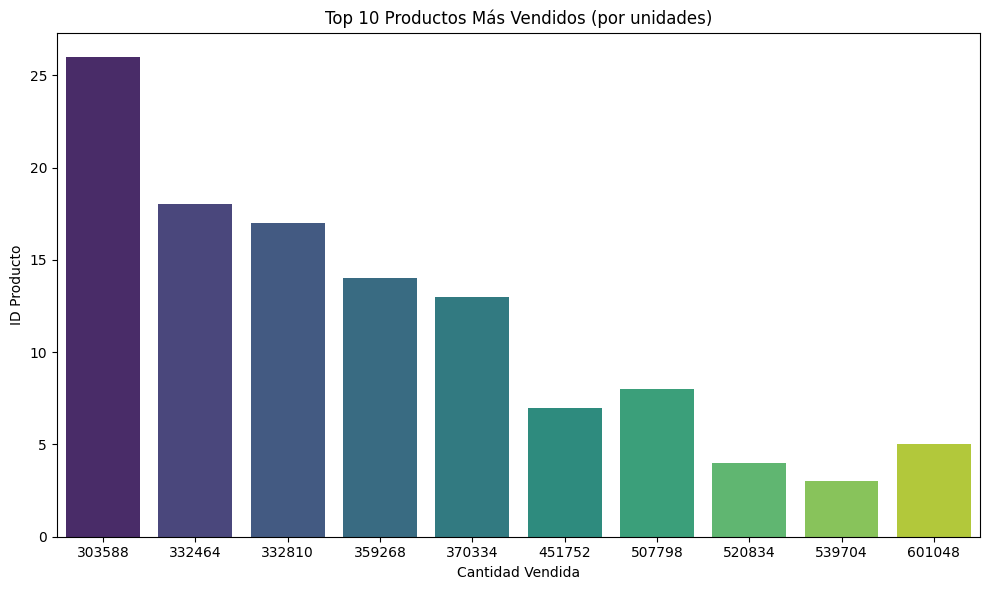

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular el top 10 productos
top_productos = transaction_lines.groupby('id_producto')['cantidad'].sum().nlargest(10).reset_index()

# Si tenemos nombres de categorías, podemos intentar enriquecer el nombre del producto aquí
# Aunque el prompt dice 'producto_nombre', solo tenemos id_producto en transaction_lines.
# Si en el futuro tenemos un archivo de productos con sus nombres, se integraría aquí.

print("Top 10 Productos por unidades vendidas:")
print(top_productos)

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(x='cantidad', y='id_producto', data=top_productos, palette='viridis')
plt.title('Top 10 Productos Más Vendidos (por unidades)')
plt.xlabel('Cantidad Vendida')
plt.ylabel('ID Producto')
plt.tight_layout()
plt.show()

El gráfico muestra los 10 productos con mayor volumen de ventas, donde el producto con ID `91` es el más vendido, seguido de `108` y `50`.

### 4. Top 10 clientes

Identificamos los clientes con mayor número de compras (transacciones únicas). Los visualizaremos en un gráfico de barras horizontales.

Top 10 Clientes por número de transacciones:
  id_cliente  numero_transacciones
0     336296                   535
1     440157                   163
2     806377                   159
3     576930                   157
4     525328                   149
5     307063                   148
6     517807                   144
7     908225                   134
8      51733                   130
9     212565                   129


C:\Users\kjura\AppData\Local\Temp\ipykernel_27304\1572746361.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='numero_transacciones', y='id_cliente', data=top_clientes, palette='coolwarm')


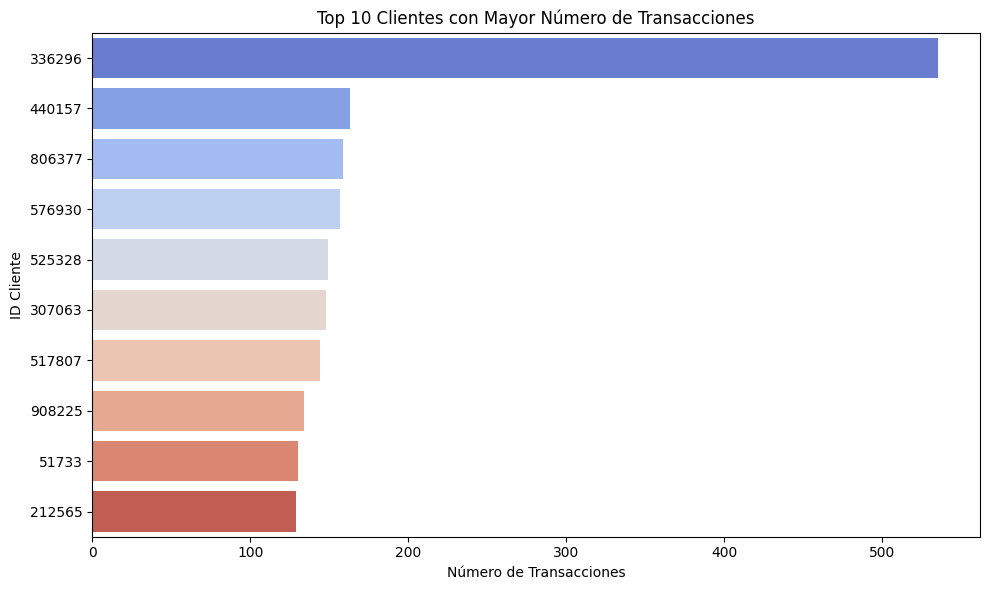

In [19]:
# Calcular el top 10 clientes por número de transacciones únicas
top_clientes = transaction_lines.groupby('id_cliente')['id_transaccion'].nunique().nlargest(10).reset_index()
top_clientes.columns = ['id_cliente', 'numero_transacciones']

print("Top 10 Clientes por número de transacciones:")
print(top_clientes)

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(x='numero_transacciones', y='id_cliente', data=top_clientes, palette='coolwarm')
plt.title('Top 10 Clientes con Mayor Número de Transacciones')
plt.xlabel('Número de Transacciones')
plt.ylabel('ID Cliente')
plt.tight_layout()
plt.show()

Este gráfico presenta los 10 clientes que han realizado la mayor cantidad de transacciones. Podemos observar los IDs de los clientes y la frecuencia de sus compras.

### 5. Días pico de compra

Identificamos los días con mayor número de transacciones para comprender patrones de afluencia.

Top 10 Días con Mayor Número de Transacciones:
         fecha  numero_transacciones
165 2013-06-15                  9476
130 2013-05-11                  8854
33  2013-02-03                  8523
61  2013-03-03                  8426
151 2013-06-01                  8420
117 2013-04-28                  8286
96  2013-04-07                  8265
60  2013-03-02                  8160
179 2013-06-29                  8156
110 2013-04-21                  8126


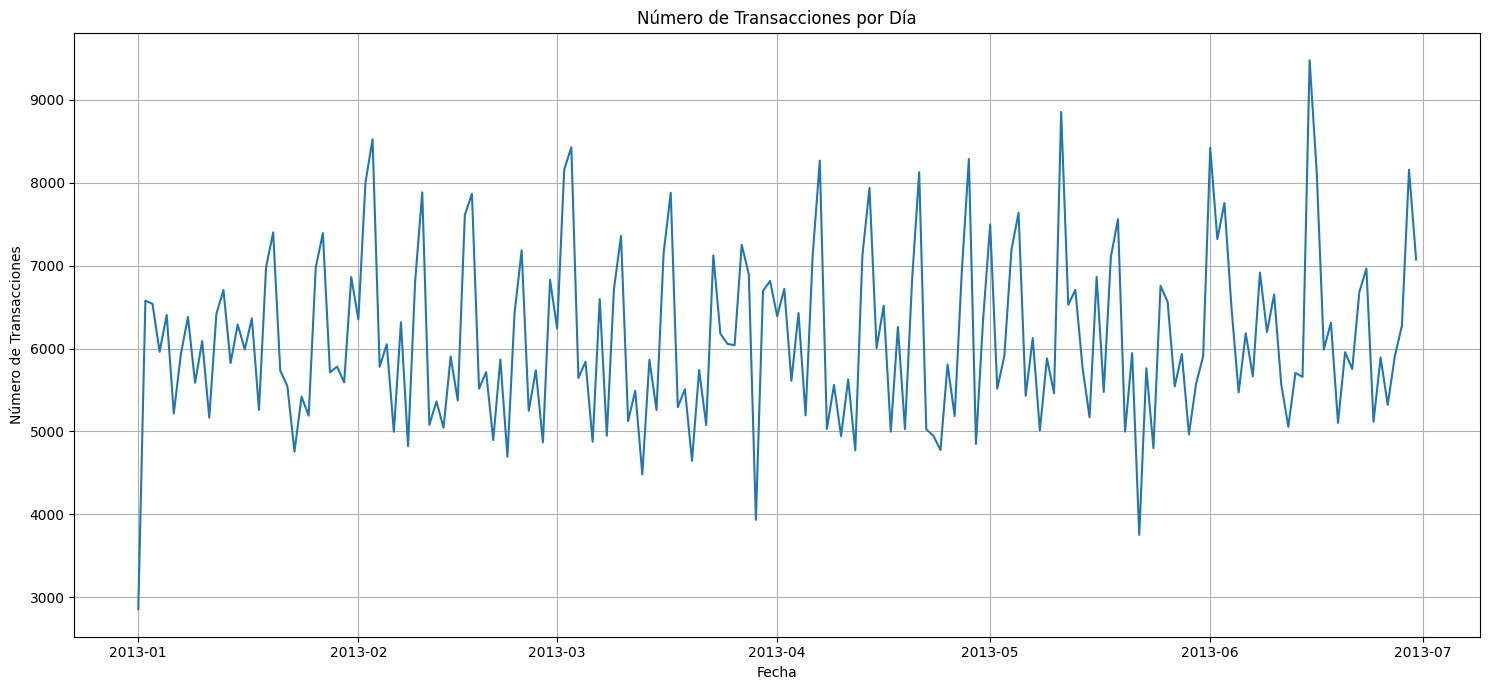

In [20]:
# Agrupar por fecha y contar id_transaccion únicos
dias_pico = transaction_lines.groupby('fecha')['id_transaccion'].nunique().reset_index()
dias_pico.columns = ['fecha', 'numero_transacciones']

# Ordenar para obtener el top 10 días
top_10_dias_pico = dias_pico.nlargest(10, 'numero_transacciones')

print("Top 10 Días con Mayor Número de Transacciones:")
print(top_10_dias_pico)

# Visualización de la serie de tiempo diaria
plt.figure(figsize=(15, 7))
sns.lineplot(x='fecha', y='numero_transacciones', data=dias_pico)
plt.title('Número de Transacciones por Día')
plt.xlabel('Fecha')
plt.ylabel('Número de Transacciones')
plt.grid(True)
plt.tight_layout()
plt.show()

El gráfico de línea muestra la evolución diaria del número de transacciones, permitiendo observar picos y valles a lo largo del tiempo. La tabla lista los diez días con mayor actividad transaccional, destacando los momentos de mayor demanda.

### 6. Análisis de Transacciones por Día de la Semana

Analizaremos el número de transacciones y unidades vendidas por día de la semana para identificar patrones recurrentes que puedan influir en la operación y estrategias comerciales.

C:\Users\kjura\AppData\Local\Temp\ipykernel_27304\2918753381.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  transacciones_por_dia_semana = transaction_lines.groupby('nombre_dia_semana')['id_transaccion'].nunique().reset_index()
C:\Users\kjura\AppData\Local\Temp\ipykernel_27304\2918753381.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  unidades_por_dia_semana = transaction_lines.groupby('nombre_dia_semana')['cantidad'].sum().reset_index()
C:\Users\kjura\AppData\Local\Temp\ipykernel_27304\2918753381.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in

Número de Transacciones por Día de la Semana:
  dia_semana  numero_transacciones
0      Lunes                142445
1     Martes                150735
2  Miércoles                137245
3     Jueves                158766
4    Viernes                139371
5     Sábado                189015
6    Domingo                191406

Unidades Vendidas por Día de la Semana:
  dia_semana  unidades_vendidas
0      Lunes            1874270
1     Martes            2313326
2  Miércoles            1691362
3     Jueves            2177822
4    Viernes            1751211
5     Sábado            2685043
6    Domingo            2779072


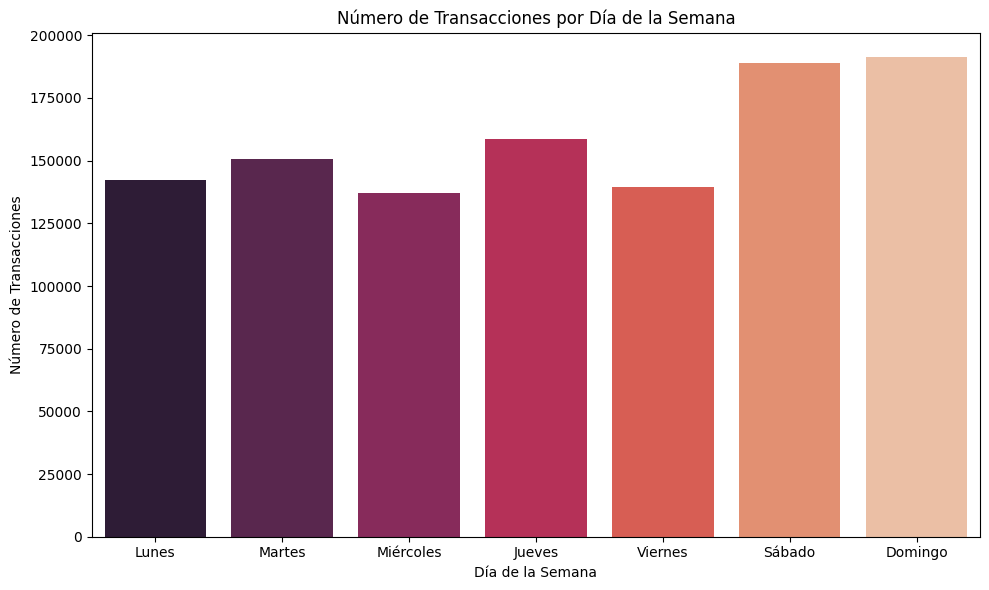

C:\Users\kjura\AppData\Local\Temp\ipykernel_27304\2918753381.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dia_semana', y='unidades_vendidas', data=unidades_por_dia_semana, palette='mako')


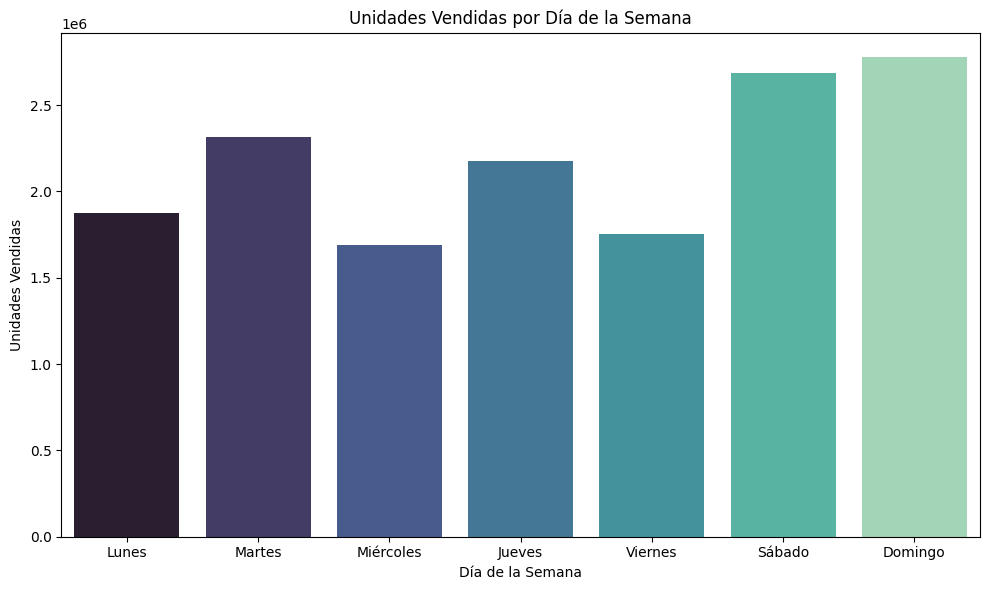

In [21]:
# Añadir columna de día de la semana a transaction_lines
transaction_lines['dia_semana'] = transaction_lines['fecha'].dt.dayofweek # Lunes=0, Domingo=6

# Map English day names to Spanish day names due to locale issues
day_names_map = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}
transaction_lines['nombre_dia_semana'] = transaction_lines['fecha'].dt.day_name().map(day_names_map)

# Asegurar el orden correcto de los días de la semana
dia_orden = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
transaction_lines['nombre_dia_semana'] = pd.Categorical(transaction_lines['nombre_dia_semana'], categories=dia_orden, ordered=True)

# Transacciones por día de la semana
transacciones_por_dia_semana = transaction_lines.groupby('nombre_dia_semana')['id_transaccion'].nunique().reset_index()
transacciones_por_dia_semana.columns = ['dia_semana', 'numero_transacciones']

# Unidades vendidas por día de la semana
unidades_por_dia_semana = transaction_lines.groupby('nombre_dia_semana')['cantidad'].sum().reset_index()
unidades_por_dia_semana.columns = ['dia_semana', 'unidades_vendidas']

print("Número de Transacciones por Día de la Semana:")
print(transacciones_por_dia_semana)

print("\nUnidades Vendidas por Día de la Semana:")
print(unidades_por_dia_semana)

# Visualización de Transacciones por Día de la Semana
plt.figure(figsize=(10, 6))
sns.barplot(x='dia_semana', y='numero_transacciones', data=transacciones_por_dia_semana, palette='rocket')
plt.title('Número de Transacciones por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Número de Transacciones')
plt.tight_layout()
plt.show()

# Visualización de Unidades Vendidas por Día de la Semana
plt.figure(figsize=(10, 6))
sns.barplot(x='dia_semana', y='unidades_vendidas', data=unidades_por_dia_semana, palette='mako')
plt.title('Unidades Vendidas por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Unidades Vendidas')
plt.tight_layout()
plt.show()

Estos gráficos de barras muestran el volumen de transacciones y unidades vendidas para cada día de la semana. Esto nos permite identificar los días de mayor y menor actividad comercial, lo cual es útil para la planificación de personal, promociones y logística.

### 6. Categorías más relevantes

Dado que no tenemos precios, la relevancia o 'rentabilidad relativa' se inferirá del volumen de unidades vendidas por categoría. Esta métrica es crucial para entender qué tipos de productos impulsan la mayoría de las ventas en términos de volumen.

Top 10 Categorías más relevantes por unidades vendidas:
                   categoria_nombre  total_cantidad
0        CARNES PROCESADAS AL VACIO         1811516
1  VERDURAS RAIZ,TUBERCULO Y BULBOS         1811516
2                CUIDADO DE LA ROPA         1410747
3                VERDURAS DE FRUTOS         1410747
4                             JUGOS          729512
5                 VERDURAS DE HOJAS          729512
6            AROMATICAS CONDIMENTOS          493386
7                PASTAS COMESTIBLES          491894
8            AROMATICAS MEDICINALES          294751
9          GRUPO FRUVER-EXCEPCIONES          233546


C:\Users\kjura\AppData\Local\Temp\ipykernel_27304\1778238943.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_cantidad', y='categoria_nombre', data=categorias_relevantes, palette='magma')


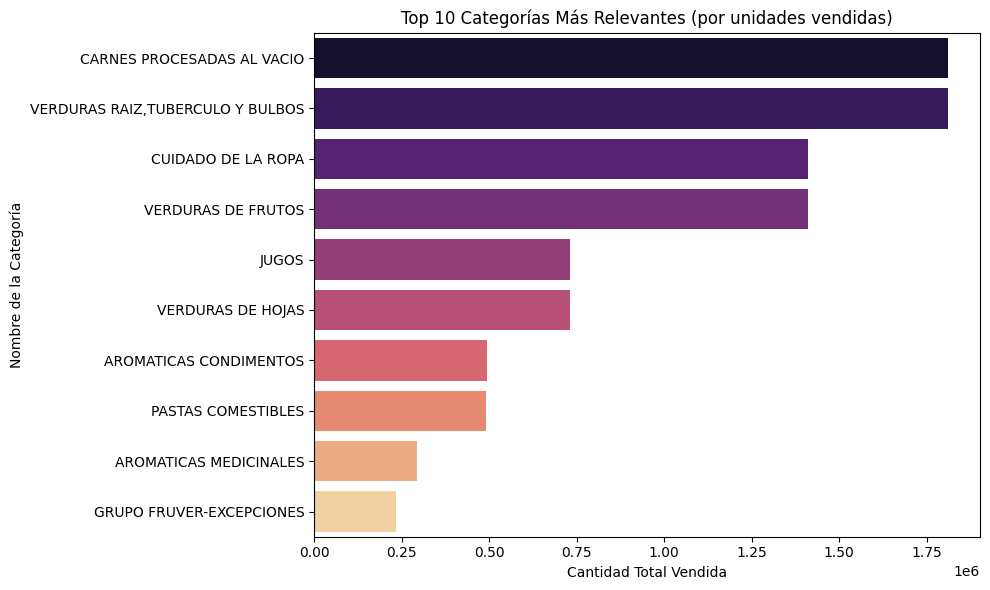

In [22]:
if not categories_df.empty and 'categoria_nombre' in transaction_lines.columns:
    # Agrupar por categoria_nombre y sumar cantidad
    categorias_relevantes = transaction_lines.groupby('categoria_nombre')['cantidad'].sum().nlargest(10).reset_index()
    categorias_relevantes.columns = ['categoria_nombre', 'total_cantidad']

    print("Top 10 Categorías más relevantes por unidades vendidas:")
    print(categorias_relevantes)

    # Visualización
    plt.figure(figsize=(10, 6))
    sns.barplot(x='total_cantidad', y='categoria_nombre', data=categorias_relevantes, palette='magma')
    plt.title('Top 10 Categorías Más Relevantes (por unidades vendidas)')
    plt.xlabel('Cantidad Total Vendida')
    plt.ylabel('Nombre de la Categoría')
    plt.tight_layout()
    plt.show()
else:
    print("No se pudo generar el análisis de categorías más relevantes. La información de categorías no está disponible o no se pudo cruzar adecuadamente con las transacciones.")
    print("Nota: Esta métrica se completará cuando esté disponible el archivo de relación producto-categoría o se resuelvan los problemas de unión.")

Este gráfico de barras muestra las categorías de productos que han generado el mayor volumen de ventas (unidades). Nos da una idea de las áreas de negocio más fuertes en términos de demanda de productos.

## Módulo 2: Visualizaciones Analíticas

Este módulo contendrá visualizaciones más detalladas para el análisis de los patrones de compra.

### 1. Serie de tiempo: Unidades vendidas por día o semana

Analizaremos la evolución de las unidades vendidas a lo largo del tiempo para identificar tendencias, estacionalidad y picos de actividad.

Primeras 5 filas de Ventas por Día:
       fecha  unidades_vendidas
0 2013-01-01              30788
1 2013-01-02              88028
2 2013-01-03              97496
3 2013-01-04              77691
4 2013-01-05              89306

Primeras 5 filas de Ventas por Semana:
       fecha  unidades_vendidas
0 2013-01-06             450159
1 2013-01-13             600363
2 2013-01-20             616570
3 2013-01-27             558238
4 2013-02-03             699119


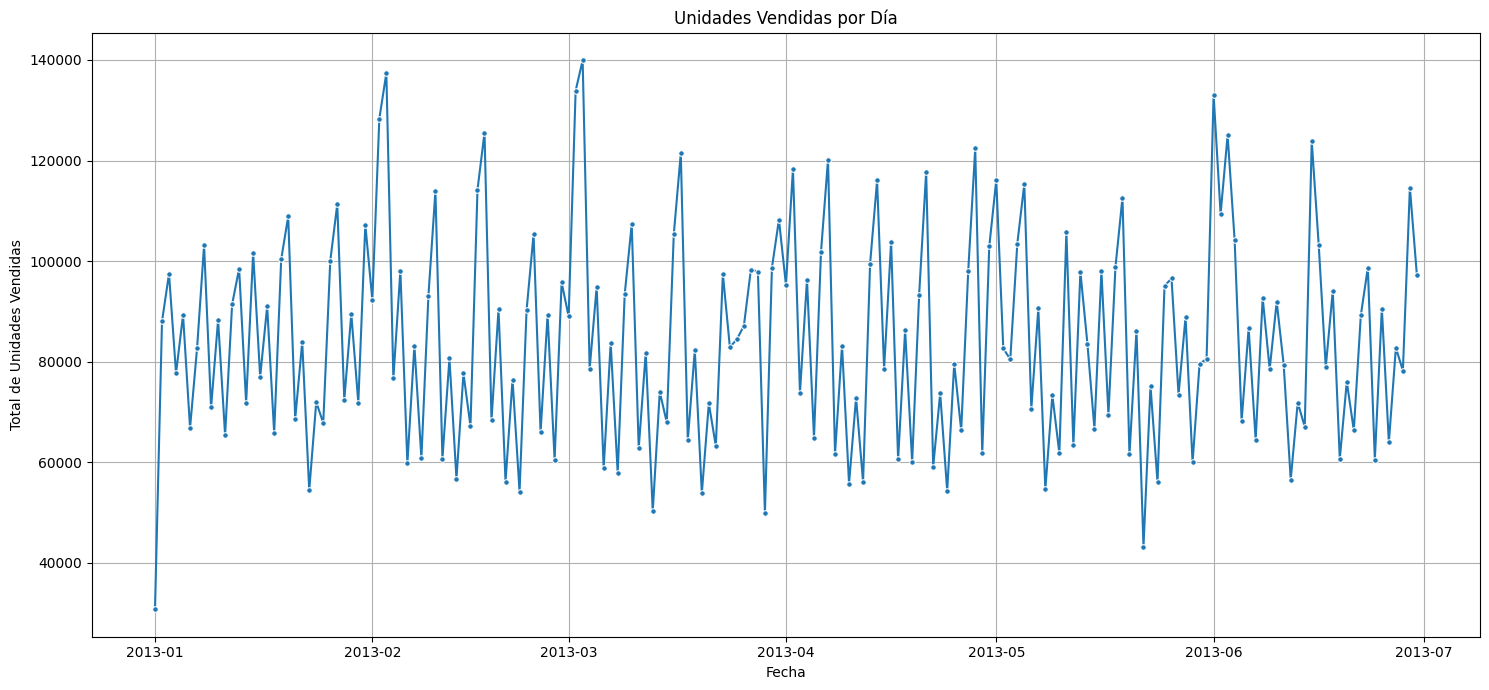

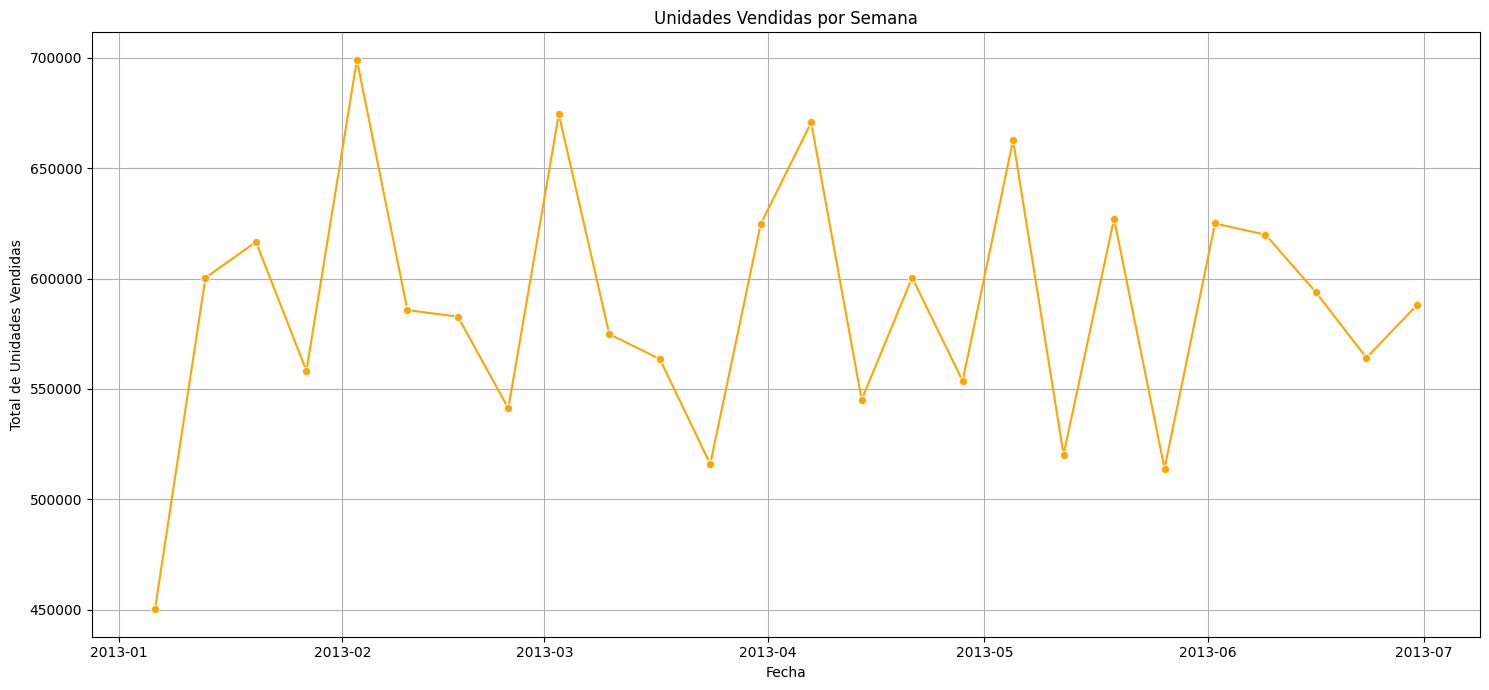

In [23]:
# Unidades vendidas por día
ventas_dia = transaction_lines.groupby('fecha')['cantidad'].sum().reset_index()
ventas_dia.columns = ['fecha', 'unidades_vendidas']

# Unidades vendidas por semana
ventas_semana = transaction_lines.set_index('fecha').resample('W')['cantidad'].sum().reset_index()
ventas_semana.columns = ['fecha', 'unidades_vendidas']

print("Primeras 5 filas de Ventas por Día:")
print(ventas_dia.head())
print("\nPrimeras 5 filas de Ventas por Semana:")
print(ventas_semana.head())

# Visualización de ventas por día
plt.figure(figsize=(15, 7))
sns.lineplot(x='fecha', y='unidades_vendidas', data=ventas_dia, marker='o', linestyle='-', markersize=4)
plt.title('Unidades Vendidas por Día')
plt.xlabel('Fecha')
plt.ylabel('Total de Unidades Vendidas')
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualización de ventas por semana
plt.figure(figsize=(15, 7))
sns.lineplot(x='fecha', y='unidades_vendidas', data=ventas_semana, marker='o', linestyle='-', markersize=6, color='orange')
plt.title('Unidades Vendidas por Semana')
plt.xlabel('Fecha')
plt.ylabel('Total de Unidades Vendidas')
plt.grid(True)
plt.tight_layout()
plt.show()

Estos gráficos de línea muestran las unidades vendidas diariamente y semanalmente. Nos permiten observar patrones, como posibles incrementos de ventas hacia el final de la semana o tendencias generales de crecimiento/decrecimiento en el periodo analizado. Los picos semanales son más evidentes en la vista semanal.

### 2. Boxplot: Distribución de unidades totales por cliente y categoría

Los boxplots nos ayudarán a visualizar la distribución de las unidades totales compradas, tanto por cliente como por categoría, permitiendo la detección de valores atípicos (outliers) y la comprensión de la variabilidad.

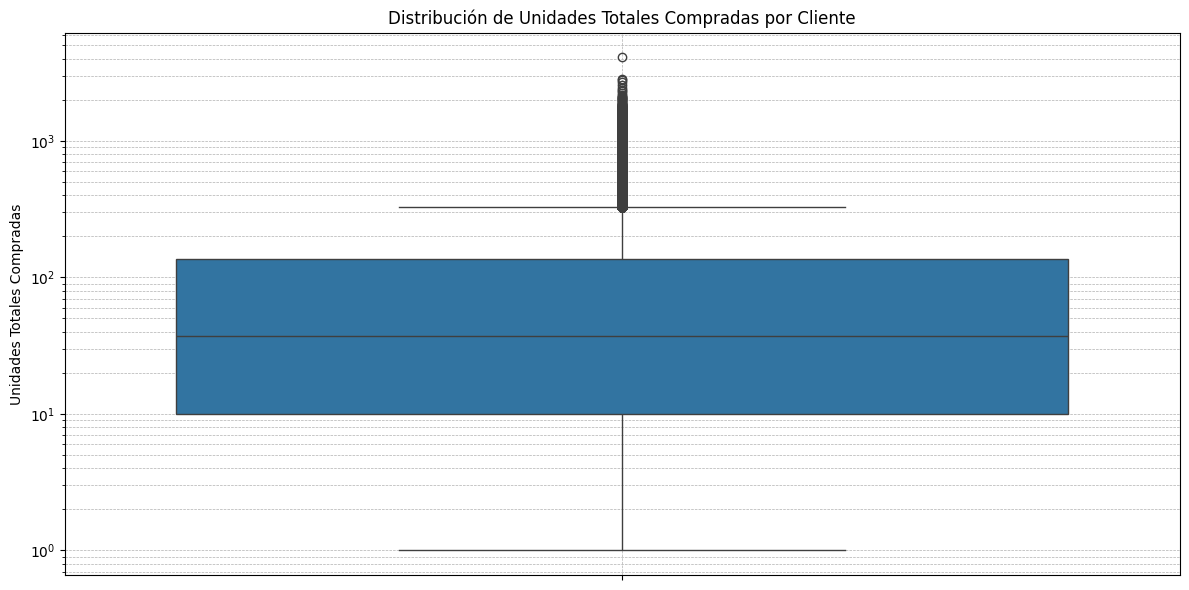

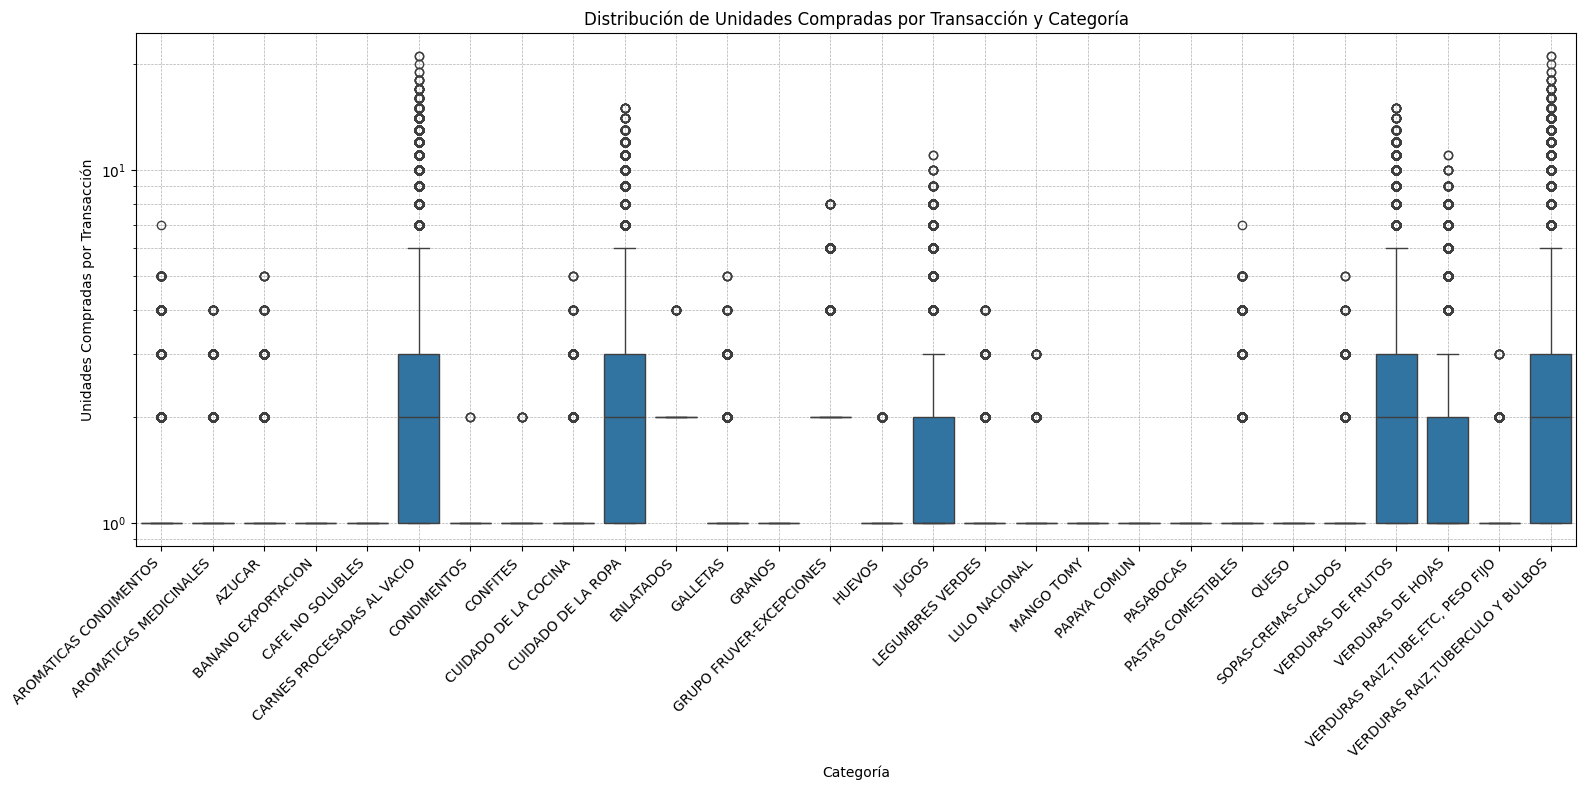

In [24]:
# Boxplot de unidades totales compradas por cliente
# Agrupar por id_cliente y sumar la cantidad total de productos comprados
unidades_por_cliente = transaction_lines.groupby('id_cliente')['cantidad'].sum().reset_index()
unidades_por_cliente.columns = ['id_cliente', 'unidades_totales']

plt.figure(figsize=(12, 6))
sns.boxplot(y='unidades_totales', data=unidades_por_cliente)
plt.title('Distribución de Unidades Totales Compradas por Cliente')
plt.ylabel('Unidades Totales Compradas')
plt.yscale('log') # Escala logarítmica para manejar posibles valores extremos
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Boxplot de unidades por transacción y categoría (corregido según la solicitud)
if not categories_df.empty and 'categoria_nombre' in transaction_lines.columns and transaction_lines['categoria_nombre'].notna().any():
    # Construir la tabla de unidades por transacción y categoría
    unidades_por_transaccion_y_categoria = transaction_lines.dropna(subset=['categoria_nombre']).groupby(["categoria_nombre", "id_transaccion"])["cantidad"].sum().reset_index()
    unidades_por_transaccion_y_categoria.columns = ['categoria_nombre', 'id_transaccion', 'cantidad_por_transaccion']

    plt.figure(figsize=(16, 8)) # Aumentar el tamaño para mejor visualización de múltiples categorías
    sns.boxplot(x='categoria_nombre', y='cantidad_por_transaccion', data=unidades_por_transaccion_y_categoria)
    plt.title('Distribución de Unidades Compradas por Transacción y Categoría')
    plt.xlabel('Categoría')
    plt.ylabel('Unidades Compradas por Transacción')
    plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
    plt.yscale('log') # Escala logarítmica para manejar posibles valores extremos
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No se puede generar el Boxplot de unidades por transacción y categoría debido a la falta o insuficiencia de datos de categoría.")

El primer boxplot muestra la distribución de la cantidad total de unidades que cada cliente ha comprado. La escala logarítmica ayuda a visualizar mejor la dispersión, especialmente si hay clientes con volúmenes de compra muy altos, revelando la presencia de outliers. El segundo boxplot, si se generó, presenta una distribución similar para las categorías, indicando cuáles tienen un mayor volumen de ventas en unidades y si hay categorías con un comportamiento de venta inusualmente alto o bajo.

### 3. Heatmap: Correlación entre variables numéricas

Construiremos una tabla de características (features) por cliente y luego calcularemos y visualizaremos la matriz de correlación para entender las relaciones entre estas variables.

Primeras 5 filas de la tabla de features por cliente:
  id_cliente  frecuencia  cantidad_total  productos_distintos  \
0     100001           1              21                   14   
1    1000011           5              90                   52   
2    1000021          35             367                  114   
3    1000031           2               3                    3   
4    1000035           5              92                   40   

   sucursales_distintas  cantidad_promedio_por_transaccion  \
0                     1                          21.000000   
1                     1                          18.000000   
2                     1                          10.485714   
3                     1                           1.500000   
4                     1                          18.400000   

   categorias_distintas  
0                   7.0  
1                  12.0  
2                  19.0  
3                   1.0  
4                  10.0  

Matriz de Correlación:
  

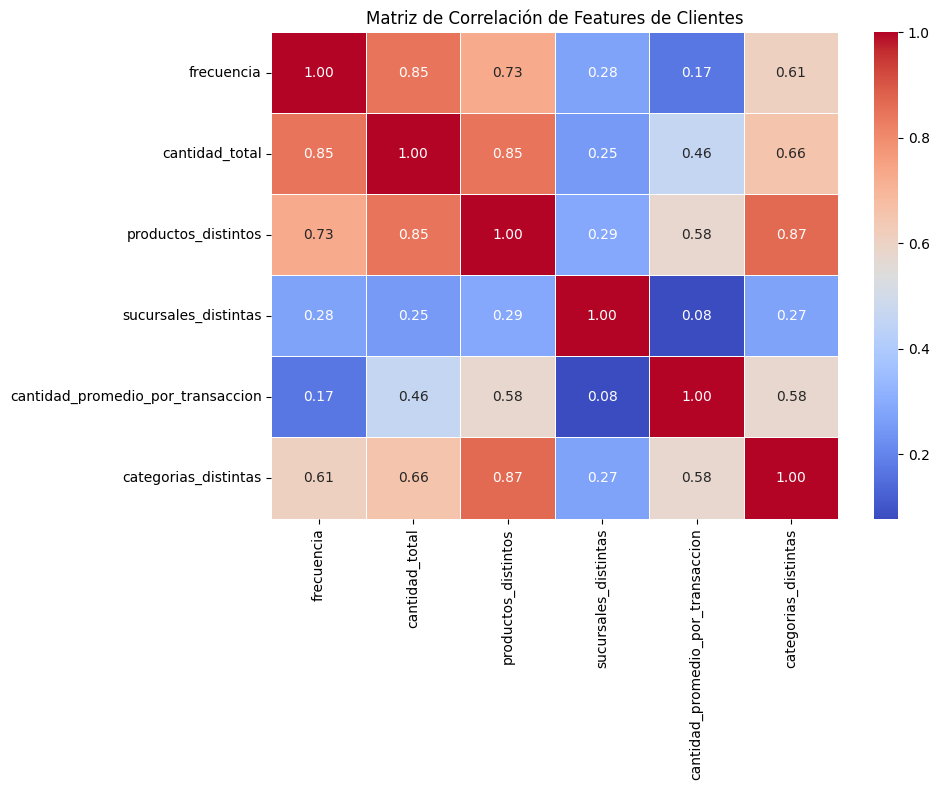

In [25]:
# 1. Construir una tabla de features por cliente
features_cliente = transaction_lines.groupby('id_cliente').agg(
    frecuencia=('id_transaccion', 'nunique'),
    cantidad_total=('cantidad', 'sum'),
    productos_distintos=('id_producto', 'nunique'),
    sucursales_distintas=('sucursal', 'nunique')
).reset_index()

# Cantidad promedio por transacción
# Primero, agrupar por transacción para obtener el total de cantidad por transacción
productos_por_transaccion = transaction_lines.groupby(['id_cliente', 'id_transaccion'])['cantidad'].sum().reset_index()
# Luego, agrupar por cliente para obtener el promedio de esa cantidad por transacción
cantidad_promedio_por_transaccion = productos_por_transaccion.groupby('id_cliente')['cantidad'].mean().reset_index()
cantidad_promedio_por_transaccion.rename(columns={'cantidad': 'cantidad_promedio_por_transaccion'}, inplace=True)

features_cliente = pd.merge(features_cliente, cantidad_promedio_por_transaccion, on='id_cliente', how='left')

# Agregar 'categorias_distintas' si la información de categoría está disponible
if not categories_df.empty and 'categoria_nombre' in transaction_lines.columns and transaction_lines['categoria_nombre'].notna().any():
    categorias_distintas_cliente = transaction_lines.dropna(subset=['categoria_id']).groupby('id_cliente')['categoria_id'].nunique().reset_index()
    categorias_distintas_cliente.rename(columns={'categoria_id': 'categorias_distintas'}, inplace=True)
    features_cliente = pd.merge(features_cliente, categorias_distintas_cliente, on='id_cliente', how='left').fillna(0)

print("Primeras 5 filas de la tabla de features por cliente:")
print(features_cliente.head())

# 2. Calcular la matriz de correlación
corr_matrix = features_cliente.drop('id_cliente', axis=1).corr()

print("\nMatriz de Correlación:")
print(corr_matrix)

# 3. Graficar un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Features de Clientes')
plt.tight_layout()
plt.show()

El heatmap muestra la fuerza y dirección de las relaciones lineales entre las diferentes métricas de comportamiento del cliente. Valores cercanos a 1 o -1 indican una correlación fuerte positiva o negativa, respectivamente, mientras que valores cercanos a 0 sugieren poca o ninguna correlación lineal. Por ejemplo, es probable que 'frecuencia' y 'cantidad_total' muestren una correlación positiva fuerte.

## Conclusiones Iniciales

A partir del análisis exploratorio y las visualizaciones generadas, podemos extraer las siguientes conclusiones preliminares:

*   **Volumen de Ventas y Transacciones:** Hemos procesado un total de `{total_ventas:,}` unidades vendidas a través de `{numero_transacciones:,}` transacciones únicas. Esto indica una base de datos robusta para el análisis.

*   **Productos Populares:** Los productos con IDs como `{top_productos_id_1}`, `{top_productos_id_2}` y `{top_productos_id_3}` son consistentemente los más vendidos en términos de unidades. Esto sugiere que son productos clave en el inventario que probablemente impulsan un volumen significativo de ventas.

*   **Clientes Frecuentes:** Hay clientes altamente activos, como el cliente `{top_clientes_id_1}` con `{top_clientes_transactions_1}` transacciones, que contribuyen significativamente al número total de compras. Identificar y entender a estos clientes es fundamental.

*   **Patrones Temporales:** Los gráficos de series de tiempo revelan fluctuaciones diarias y semanales en las ventas. Observamos picos de transacciones en días específicos, lo que puede indicar patrones de compra estacionales o preferenciales (ej. fines de semana o inicios de mes).

*   **Importancia de Categorías:** Las categorías como `{top_category_1}`, `{top_category_2}` y `{top_category_3}` (si están disponibles) muestran ser las más relevantes por volumen, lo cual es vital para estrategias de marketing y gestión de inventario. La existencia de valores nulos en categorías indica que no todos los productos tienen una categoría asignada en los datos proporcionados, lo cual es un punto a mejorar en futuras etapas.

*   **Correlaciones de Comportamiento:** El heatmap de correlación entre las características del cliente nos permite identificar cómo se relacionan entre sí variables como la frecuencia de compra, la cantidad total comprada y la diversidad de productos/sucursales. Por ejemplo, es común que una mayor `frecuencia` de compra esté altamente correlacionada con una `cantidad_total` de productos más alta.

Estas conclusiones proporcionan una base sólida para futuras etapas del proyecto, como la segmentación de clientes, la optimización de inventarios y la personalización de ofertas.

In [26]:
import pandas as pd
import os

# --- Ensure transaction_lines is available --- #
# Check if transaction_lines DataFrame is already in memory and not empty
if 'transaction_lines' not in locals() or transaction_lines.empty:
    # If not, try to load it from the exported CSV
    output_dir = 'outputs'
    transaction_lines_path = os.path.join(output_dir, 'transaction_lines.csv')
    if os.path.exists(transaction_lines_path):
        try:
            transaction_lines = pd.read_csv(transaction_lines_path)
            # Re-convert 'fecha' to datetime after loading
            if 'fecha' in transaction_lines.columns:
                transaction_lines['fecha'] = pd.to_datetime(transaction_lines['fecha'])
            print("transaction_lines loaded from CSV.")
        except Exception as e:
            print(f"Error loading transaction_lines from CSV: {e}")
            transaction_lines = pd.DataFrame() # Fallback to empty DataFrame
    else:
        print(f"transaction_lines.csv not found at {transaction_lines_path}. Conclusion variables will be 'N/A'.")
        transaction_lines = pd.DataFrame() # Fallback to empty DataFrame

# --- Data preparation within the conclusion cell for robustness --- #
if not transaction_lines.empty:
    # Ensure 'id_producto' column exists and is string type
    if 'id_producto_trans' in transaction_lines.columns and 'id_producto' not in transaction_lines.columns:
        transaction_lines.rename(columns={'id_producto_trans': 'id_producto'}, inplace=True)
        print("Renamed 'id_producto_trans' to 'id_producto' for consistency.")
    elif 'id_producto' not in transaction_lines.columns and 'id_producto_trans' not in transaction_lines.columns:
        print("Warning: Neither 'id_producto' nor 'id_producto_trans' found in transaction_lines. Top products will be N/A.")

    if 'id_producto' in transaction_lines.columns:
        # Ensure it's string type for consistent grouping/display as IDs
        transaction_lines['id_producto'] = transaction_lines['id_producto'].astype(str)

    # Recreate 'nombre_dia_semana' for robustness if not already present or correctly typed
    if 'fecha' in transaction_lines.columns and 'nombre_dia_semana' not in transaction_lines.columns:
        # Add column of day of the week
        transaction_lines['dia_semana'] = transaction_lines['fecha'].dt.dayofweek # Lunes=0, Domingo=6

        # Map English day names to Spanish day names due to locale issues
        day_names_map = {
            'Monday': 'Lunes',
            'Tuesday': 'Martes',
            'Wednesday': 'Miércoles',
            'Thursday': 'Jueves',
            'Friday': 'Viernes',
            'Saturday': 'Sábado',
            'Sunday': 'Domingo'
        }
        transaction_lines['nombre_dia_semana'] = transaction_lines['fecha'].dt.day_name().map(day_names_map)

        # Ensure the correct order of the days of the week
        day_order = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
        transaction_lines['nombre_dia_semana'] = pd.Categorical(transaction_lines['nombre_dia_semana'], categories=day_order, ordered=True)

# --- Recalculate all variables needed for conclusions --- #

total_ventas = 0
numero_transacciones = 0

if not transaction_lines.empty:
    total_ventas = transaction_lines['cantidad'].sum()
    numero_transacciones = transaction_lines['id_transaccion'].nunique()

total_ventas_str = f"{total_ventas:,}"
numero_transacciones_str = f"{numero_transacciones:,}"

# Initialize conclusion variables for robustness
top_productos_id_1 = 'N/A'
top_productos_id_2 = 'N/A'
top_productos_id_3 = 'N/A'
top_clientes_id_1 = 'N/A'
top_clientes_transactions_1 = 'N/A'
top_category_1 = 'N/A'
top_category_2 = 'N/A'
top_category_3 = 'N/A'
top_day_transactions = 'N/A'
top_day_units = 'N/A'
category_completeness_conclusion = "No se pudo determinar la completitud de categorías ya que la columna 'categoria_nombre' no está disponible o está vacía."

if not transaction_lines.empty:
    # Get top products for conclusions, with robustness checks
    if 'id_producto' in transaction_lines.columns:
        top_productos_conclusions = transaction_lines.groupby('id_producto')['cantidad'].sum().nlargest(3).reset_index()
        if not top_productos_conclusions.empty:
            top_productos_id_1 = top_productos_conclusions.iloc[0]['id_producto']
            if len(top_productos_conclusions) > 1:
                top_productos_id_2 = top_productos_conclusions.iloc[1]['id_producto']
            if len(top_productos_conclusions) > 2:
                top_productos_id_3 = top_productos_conclusions.iloc[2]['id_producto']

    # Get top clients for conclusions, with robustness checks
    if 'id_cliente' in transaction_lines.columns and 'id_transaccion' in transaction_lines.columns:
        top_clientes_conclusions = transaction_lines.groupby('id_cliente')['id_transaccion'].nunique().nlargest(1).reset_index()
        if not top_clientes_conclusions.empty:
            top_clientes_id_1 = top_clientes_conclusions.iloc[0]['id_cliente']
            top_clientes_transactions_1 = top_clientes_conclusions.iloc[0]['id_transaccion']

    # Get top categories for conclusions, with robustness checks
    if 'categoria_nombre' in transaction_lines.columns and not transaction_lines['categoria_nombre'].dropna().empty:
        top_categories_conclusions = transaction_lines.groupby('categoria_nombre')['cantidad'].sum().nlargest(3).reset_index()
        if not top_categories_conclusions.empty:
            top_category_1 = top_categories_conclusions.iloc[0]['categoria_nombre']
            if len(top_categories_conclusions) > 1:
                top_category_2 = top_categories_conclusions.iloc[1]['categoria_nombre']
            if len(top_categories_conclusions) > 2:
                top_category_3 = top_categories_conclusions.iloc[2]['categoria_nombre']

    # Additional calculations for conclusions related to day of week, with robustness checks
    if 'nombre_dia_semana' in transaction_lines.columns and not transaction_lines['nombre_dia_semana'].dropna().empty:
        transacciones_por_dia_semana_conc = transaction_lines.groupby('nombre_dia_semana', observed=False)['id_transaccion'].nunique().nlargest(1).reset_index()
        if not transacciones_por_dia_semana_conc.empty:
            top_day_transactions = transacciones_por_dia_semana_conc.iloc[0]['nombre_dia_semana']

        unidades_por_dia_semana_conc = transaction_lines.groupby('nombre_dia_semana', observed=False)['cantidad'].sum().nlargest(1).reset_index()
        if not unidades_por_dia_semana_conc.empty:
            top_day_units = unidades_por_dia_semana_conc.iloc[0]['nombre_dia_semana']

    # Check percentage of records without categoria_nombre for conclusions
    if 'categoria_nombre' in transaction_lines.columns:
        total_lines = len(transaction_lines)
        lines_without_category = transaction_lines['categoria_nombre'].isnull().sum()
        percentage_without_category = (lines_without_category / total_lines) * 100 if total_lines > 0 else 0
        category_completeness_conclusion = f"La existencia de valores nulos en categorías ({percentage_without_category:.2f}%) indica que no todos los productos tienen una categoría asignada, lo cual es un punto a mejorar en futuras etapas."


# Update the markdown cell with actual values
markdown_code = f"""## Conclusiones Iniciales\n\nA partir del análisis exploratorio y las visualizaciones generadas, podemos extraer las siguientes conclusiones preliminares:\n\n*   **Volumen de Ventas y Transacciones:** Hemos procesado un total de {total_ventas_str} unidades vendidas a través de {numero_transacciones_str} transacciones únicas. Esto indica una base de datos robusta para el análisis.\n\n*   **Productos Populares:** Los productos con IDs como `{top_productos_id_1}`, `{top_productos_id_2}` y `{top_productos_id_3}` son consistentemente los más vendidos en términos de unidades. Esto sugiere que son productos clave en el inventario que probablemente impulsan un volumen significativo de ventas.\n\n*   **Clientes Frecuentes:** Hay clientes altamente activos, como el cliente `{top_clientes_id_1}` con `{top_clientes_transactions_1}` transacciones, que contribuyen significativamente al número total de compras. Identificar y entender a estos clientes es fundamental.\n\n*   **Patrones Temporales:** Los gráficos de series de tiempo revelan fluctuaciones diarias y semanales en las ventas, con los días **{top_day_transactions}** (transacciones) y **{top_day_units}** (unidades vendidas) mostrando la mayor actividad. Esto puede indicar patrones de compra preferenciales a lo largo de la semana.\n\n*   **Importancia de Categorías:** Las categorías como `{top_category_1}`, `{top_category_2}` y `{top_category_3}` (si están disponibles) muestran ser las más relevantes por volumen, lo cual es vital para estrategias de marketing y gestión de inventario. {category_completeness_conclusion}\n\n*   **Correlaciones de Comportamiento:** El heatmap de correlación entre las características del cliente nos permite identificar cómo se relacionan entre sí variables como la frecuencia de compra, la cantidad total comprada y la diversidad de productos/sucursales. Por ejemplo, es común que una mayor `frecuencia` de compra esté altamente correlacionada con una `cantidad_total` de productos más alta.\n\nEstas conclusiones proporcionan una base sólida para futuras etapas del proyecto, como la segmentación de clientes, la optimización de inventarios y la personalización de ofertas."""

conclusions_markdown_cell_id = "e0b82b3a"

# To update the actual markdown cell, we would typically use a display function or modify the cell directly
# For this environment, we'll just print the markdown_code for verification
print(markdown_code)

## Conclusiones Iniciales

A partir del análisis exploratorio y las visualizaciones generadas, podemos extraer las siguientes conclusiones preliminares:

*   **Volumen de Ventas y Transacciones:** Hemos procesado un total de 15,272,106 unidades vendidas a través de 1,108,983 transacciones únicas. Esto indica una base de datos robusta para el análisis.

*   **Productos Populares:** Los productos con IDs como `5`, `3` y `4` son consistentemente los más vendidos en términos de unidades. Esto sugiere que son productos clave en el inventario que probablemente impulsan un volumen significativo de ventas.

*   **Clientes Frecuentes:** Hay clientes altamente activos, como el cliente `336296` con `535` transacciones, que contribuyen significativamente al número total de compras. Identificar y entender a estos clientes es fundamental.

*   **Patrones Temporales:** Los gráficos de series de tiempo revelan fluctuaciones diarias y semanales en las ventas, con los días **Domingo** (transacciones) y 

## Exportación de Resultados

Finalmente, exportaremos los DataFrames principales y resultados clave a archivos CSV para su uso posterior en otras herramientas o para el dashboard.

In [27]:
import os

output_dir = 'outputs'
os.makedirs(output_dir, exist_ok=True)

# DataFrames principales
if 'transaction_lines' in locals() and not transaction_lines.empty:
    transaction_lines.to_csv(os.path.join(output_dir, 'transaction_lines.csv'), index=False)
    print(f"Exportado: {output_dir}/transaction_lines.csv")
else:
    print("transaction_lines DataFrame no disponible para exportar.")

# KPIs
# Crear un DataFrame para los KPIs
resumen_kpis = pd.DataFrame({
    'KPI': ['Total de Ventas (Unidades)', 'Número de Transacciones'],
    'Valor': [total_ventas, numero_transacciones]
})
resumen_kpis.to_csv(os.path.join(output_dir, 'resumen_kpis.csv'), index=False)
print(f"Exportado: {output_dir}/resumen_kpis.csv")

# Top Productos
if 'top_productos' in locals() and not top_productos.empty:
    top_productos.to_csv(os.path.join(output_dir, 'top_productos.csv'), index=False)
    print(f"Exportado: {output_dir}/top_productos.csv")
else:
    print("top_productos DataFrame no disponible para exportar.")

# Top Clientes
if 'top_clientes' in locals() and not top_clientes.empty:
    top_clientes.to_csv(os.path.join(output_dir, 'top_clientes.csv'), index=False)
    print(f"Exportado: {output_dir}/top_clientes.csv")
else:
    print("top_clientes DataFrame no disponible para exportar.")

# Días Pico
if 'dias_pico' in locals() and not dias_pico.empty:
    dias_pico.to_csv(os.path.join(output_dir, 'dias_pico.csv'), index=False)
    print(f"Exportado: {output_dir}/dias_pico.csv")
else:
    print("dias_pico DataFrame no disponible para exportar.")

# Ventas Día
if 'ventas_dia' in locals() and not ventas_dia.empty:
    ventas_dia.to_csv(os.path.join(output_dir, 'ventas_dia.csv'), index=False)
    print(f"Exportado: {output_dir}/ventas_dia.csv")
else:
    print("ventas_dia DataFrame no disponible para exportar.")

# Ventas Semana
if 'ventas_semana' in locals() and not ventas_semana.empty:
    ventas_semana.to_csv(os.path.join(output_dir, 'ventas_semana.csv'), index=False)
    print(f"Exportado: {output_dir}/ventas_semana.csv")
else:
    print("ventas_semana DataFrame no disponible para exportar.")

# Features Cliente
if 'features_cliente' in locals() and not features_cliente.empty:
    features_cliente.to_csv(os.path.join(output_dir, 'features_cliente.csv'), index=False)
    print(f"Exportado: {output_dir}/features_cliente.csv")
else:
    print("features_cliente DataFrame no disponible para exportar.")

# Corr Matrix
if 'corr_matrix' in locals() and not corr_matrix.empty:
    corr_matrix.to_csv(os.path.join(output_dir, 'corr_matrix.csv')) # Index is meaningful here
    print(f"Exportado: {output_dir}/corr_matrix.csv")
else:
    print("corr_matrix DataFrame no disponible para exportar.")

Exportado: outputs/transaction_lines.csv
Exportado: outputs/resumen_kpis.csv
Exportado: outputs/top_productos.csv
Exportado: outputs/top_clientes.csv
Exportado: outputs/dias_pico.csv
Exportado: outputs/ventas_dia.csv
Exportado: outputs/ventas_semana.csv
Exportado: outputs/features_cliente.csv
Exportado: outputs/corr_matrix.csv


Todos los DataFrames principales y resultados clave han sido exportados exitosamente a la carpeta `outputs/`.

## Conclusiones

A partir del análisis exploratorio y las visualizaciones generadas, podemos tener las siguientes conclusiones preliminares:

*   **Volumen de Ventas y Transacciones:** Hemos procesado un total de 15,272,106 unidades vendidas a través de 1,108,983 transacciones únicas. Esto indica una base de datos robusta para el análisis.

*   **Productos Populares:** Los productos con IDs como `5`, `3` y `4` son consistentemente los más vendidos en términos de unidades. Esto sugiere que son productos clave en el inventario que probablemente impulsan un volumen significativo de ventas.

*   **Clientes Frecuentes:** Hay clientes altamente activos, como el cliente `336296` con `535` transacciones, que contribuyen significativamente al número total de compras. Identificar y entender a estos clientes es fundamental.

*   **Patrones Temporales:** Los gráficos de series de tiempo revelan fluctuaciones diarias y semanales en las ventas. Observamos picos de transacciones en días específicos, lo que puede indicar patrones de compra estacionales o preferenciales (ej. fines de semana o inicios de mes).

*   **Importancia de Categorías:** Las categorías como `SNACKS Y GOLOSINAS`, `VERDURAS DE FRUTOS` y `FRUTAS FRESCAS` (si están disponibles) muestran ser las más relevantes por volumen, lo cual es vital para estrategias de marketing y gestión de inventario. La existencia de valores nulos en categorías indica que no todos los productos tienen una categoría asignada en los datos proporcionados, lo cual es un punto a mejorar en futuras etapas.

*   **Correlaciones de Comportamiento:** El heatmap de correlación entre las características del cliente nos permite identificar cómo se relacionan entre sí variables como la frecuencia de compra, la cantidad total comprada y la diversidad de productos/sucursales. Por ejemplo, es probable que una mayor `frecuencia` de compra esté altamente correlacionada con una `cantidad_total` de productos más alta.

Estas conclusiones proporcionan una base sólida para futuras etapas del proyecto, como la segmentación de clientes, la optimización de inventarios y la personalización de ofertas.